# Banking Intent Classification using DistilBERT

## Objective

The objective of this project is to classify customer banking queries into one of the predefined intent categories using the DistilBERT transformer model.

The model is fine-tuned on the BANKING77 dataset and can predict the intent of a customer query with high accuracy.

---

## Problem Statement

Banks receive thousands of customer queries every day.

Examples:

- My card has not arrived.
- I forgot my PIN.
- Why was my transfer declined?
- I need a refund.

Instead of manually routing these queries, an NLP model can automatically classify the user's intent.

---

## Dataset

Dataset: BANKING77

- Training Samples: 10,003
- Testing Samples: 3,080
- Total Classes: 77

---

## Model

DistilBERT

---

## Libraries

- Pandas
- NumPy
- PyTorch
- Transformers
- Scikit-learn
- Matplotlib
- streamlit
- tqdm

---

## Importing Libraries (For data preprocessing)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Datasets

In [9]:
train_df = pd.read_csv("../Data/train.csv")

In [10]:
train_df

,text,category
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival
...,...,...
9998,You provide support in what countries?,country_support
9999,What countries are you supporting?,country_support
10000,What countries are getting support?,country_support
10001,Are cards available in the EU?,country_support


In [12]:
test_df = pd.read_csv("../Data/test.csv")

In [13]:
test_df

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
...,...,...
3075,"If i'm not in the UK, can I still get a card?",country_support
3076,How many countries do you support?,country_support
3077,What countries do you do business in?,country_support
3078,What are the countries you operate in.,country_support


In [14]:
#Shape
print("Training Shape :", train_df.shape)
print("Testing Shape :", test_df.shape)

Training Shape : (10003, 2)
Testing Shape : (3080, 2)


In [15]:
#Missing values
train_df.isnull().sum()

text        0
category    0
dtype: int64

In [16]:
test_df.isnull().sum()

text        0
category    0
dtype: int64

In [17]:
#Duplicate Records 
train_df.drop_duplicates()
test_df.drop_duplicates()

,text,category
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival
...,...,...
3075,"If i'm not in the UK, can I still get a card?",country_support
3076,How many countries do you support?,country_support
3077,What countries do you do business in?,country_support
3078,What are the countries you operate in.,country_support


In [18]:
#Number of Intent Classes
train_df["category"].nunique()

77

In [19]:
#Listing all Intents
sorted(train_df["category"].unique())

['Refund_not_showing_up',
 'activate_my_card',
 'age_limit',
 'apple_pay_or_google_pay',
 'atm_support',
 'automatic_top_up',
 'balance_not_updated_after_bank_transfer',
 'balance_not_updated_after_cheque_or_cash_deposit',
 'beneficiary_not_allowed',
 'cancel_transfer',
 'card_about_to_expire',
 'card_acceptance',
 'card_arrival',
 'card_delivery_estimate',
 'card_linking',
 'card_not_working',
 'card_payment_fee_charged',
 'card_payment_not_recognised',
 'card_payment_wrong_exchange_rate',
 'card_swallowed',
 'cash_withdrawal_charge',
 'cash_withdrawal_not_recognised',
 'change_pin',
 'compromised_card',
 'contactless_not_working',
 'country_support',
 'declined_card_payment',
 'declined_cash_withdrawal',
 'declined_transfer',
 'direct_debit_payment_not_recognised',
 'disposable_card_limits',
 'edit_personal_details',
 'exchange_charge',
 'exchange_rate',
 'exchange_via_app',
 'extra_charge_on_statement',
 'failed_transfer',
 'fiat_currency_support',
 'get_disposable_virtual_card',
 '

In [20]:
#Intent Distribution
intent_counts = train_df["category"].value_counts()
intent_counts.head()

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
Name: count, dtype: int64

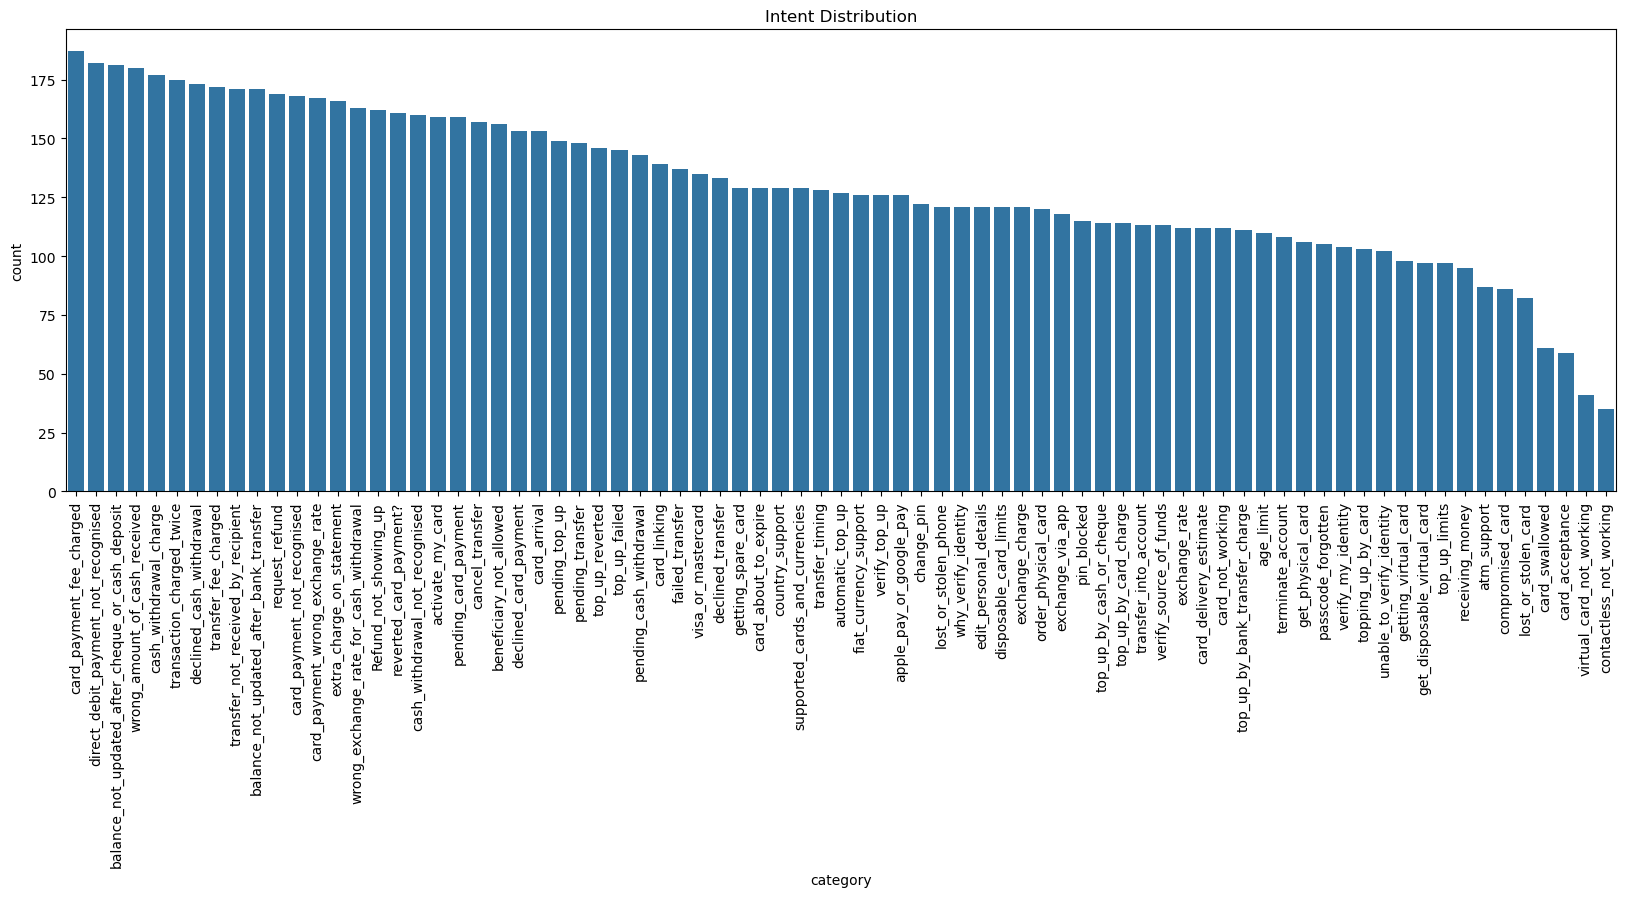

In [21]:
# Plot Class Distribution
import seaborn as sns
plt.figure(figsize=(20,6))
sns.countplot(
    x = "category",
    data = train_df,
    order = train_df["category"].value_counts().index
)

plt.xticks(rotation = 90)
plt.title("Intent Distribution")
plt.show()

In [22]:
# Query Length
train_df["query_length"] = train_df["text"].apply(len)
test_df["query_length"] = test_df["text"].apply(len)

In [23]:
train_df["query_length"].describe()

count    10003.000000
mean        59.473758
std         40.867901
min         13.000000
25%         36.000000
50%         47.000000
75%         64.000000
max        433.000000
Name: query_length, dtype: float64

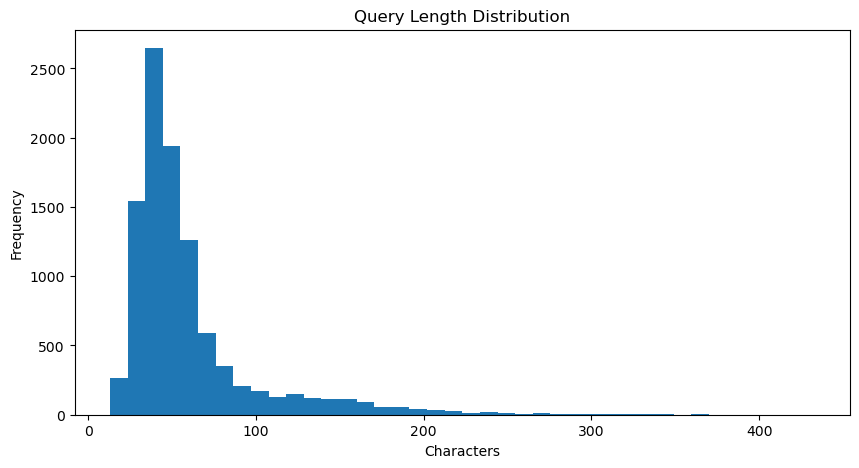

In [24]:
# Query Length Distribution
plt.figure(figsize = (10,5))
plt.hist(train_df["query_length"], bins = 40)
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.title("Query Length Distribution")
plt.show()

In [25]:
# Label Encoding
encoder = LabelEncoder()
train_df["label"] = encoder.fit_transform(
    train_df["category"]
)
test_df["label"] = encoder.transform(
    test_df["category"]
)

In [26]:
# Check Encoding
train_df.head()

,text,category,query_length,label
0,I am still waiting on my card?,card_arrival,30,12
1,What can I do if my card still hasn't arrived ...,card_arrival,60,12
2,I have been waiting over a week. Is the card s...,card_arrival,58,12
3,Can I track my card while it is in the process...,card_arrival,59,12
4,"How do I know if I will get my card, or if it ...",card_arrival,54,12


In [29]:
#Save Label Mapping
import json

label_map = {
    int(i): label
    for i, label in enumerate(encoder.classes_)
}

with open("../Data/Label_mapping.json","w") as f:
    json.dump(label_map, f, indent = 4)

In [30]:
label_map

{0: 'Refund_not_showing_up',
 1: 'activate_my_card',
 2: 'age_limit',
 3: 'apple_pay_or_google_pay',
 4: 'atm_support',
 5: 'automatic_top_up',
 6: 'balance_not_updated_after_bank_transfer',
 7: 'balance_not_updated_after_cheque_or_cash_deposit',
 8: 'beneficiary_not_allowed',
 9: 'cancel_transfer',
 10: 'card_about_to_expire',
 11: 'card_acceptance',
 12: 'card_arrival',
 13: 'card_delivery_estimate',
 14: 'card_linking',
 15: 'card_not_working',
 16: 'card_payment_fee_charged',
 17: 'card_payment_not_recognised',
 18: 'card_payment_wrong_exchange_rate',
 19: 'card_swallowed',
 20: 'cash_withdrawal_charge',
 21: 'cash_withdrawal_not_recognised',
 22: 'change_pin',
 23: 'compromised_card',
 24: 'contactless_not_working',
 25: 'country_support',
 26: 'declined_card_payment',
 27: 'declined_cash_withdrawal',
 28: 'declined_transfer',
 29: 'direct_debit_payment_not_recognised',
 30: 'disposable_card_limits',
 31: 'edit_personal_details',
 32: 'exchange_charge',
 33: 'exchange_rate',
 34: 

In [32]:
# Saving Processed Data
train_df.to_csv(
    "../Data/train_processed.csv",
    index = False
)

test_df.to_csv(
    "../Data/test_processed.csv",
    index = False
)